# Log Transformation สำหรับการปรับปรุงภาพ

Notebook นี้ใช้สอนแนวคิด **log transformation** ในงานประมวลผลภาพระดับเทา (grayscale image) โดยเน้นโค้ดที่สั้น อ่านง่าย และเชื่อมกับหลักการโดยตรง

**เป้าหมายการเรียนรู้**

- เข้าใจว่าสูตร log transform เปลี่ยนค่าความเข้มของ pixel อย่างไร
- เห็นผลว่าบริเวณมืดถูกขยายรายละเอียด ส่วนบริเวณสว่างถูกบีบช่วงค่า
- คำนวณ log transform ด้วย NumPy ได้อย่างถูกต้อง
- รู้จัก lookup table (LUT) ซึ่งเป็นวิธีที่เร็วเมื่อ mapping มีค่าได้เพียง 0-255


## หลักการของ Log Transformation

ให้ `r` คือค่าความเข้มเดิมของ pixel และ `s` คือค่าหลังแปลง

$$
s = c \log(1 + r)
$$

เหตุผลที่ใช้ `1 + r` คือทำให้ `r = 0` คำนวณได้ เพราะ $\log(1)=0$

สำหรับภาพ 8-bit ค่าความเข้มอยู่ในช่วง 0 ถึง 255 จึงมักเลือกค่าคงที่

$$
c = \frac{255}{\log(1 + r_{\max})}
$$

โดย $r_{\max}$ คือค่าความเข้มสูงสุดในภาพอินพุต วิธีนี้ทำให้ค่าที่สว่างที่สุดในภาพถูกปรับให้ใกล้ 255

**ผลของการแปลง**

- pixel ค่าน้อย เช่นบริเวณมืด จะถูกเพิ่มขึ้นค่อนข้างมาก ทำให้เห็นรายละเอียดมากขึ้น
- pixel ค่าสูง เช่นบริเวณสว่าง จะเพิ่มขึ้นน้อยลง เป็นการบีบช่วงค่าความสว่าง
- ฟังก์ชัน log เป็นฟังก์ชันเพิ่มเสมอ ลำดับความสว่างเดิมจึงยังไม่กลับด้าน


## 1) เตรียมเครื่องมือ

ใช้ `cv2.imread()` สำหรับอ่านภาพ และใช้ `matplotlib` สำหรับแสดงผลใน notebook เพื่อให้รันได้สะดวกใน Jupyter


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = "./images/dark2.png"


## 2) อ่านภาพระดับเทา

การทำ log transform ในตัวอย่างนี้ใช้ภาพ grayscale เพื่อให้เห็น mapping ระหว่างค่า pixel เดิมและค่า pixel ใหม่ได้ชัดเจน


In [2]:
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Cannot read image: {IMAGE_PATH}")

print(f"shape   : {img.shape}")
print(f"dtype   : {img.dtype}")
print(f"min/max : {img.min()} / {img.max()}")


shape   : (700, 700)
dtype   : uint8
min/max : 2 / 50


## 3) คำนวณ Log Transform

ขั้นตอนสำคัญมี 3 ส่วน

1. แปลงภาพเป็น `float32` ก่อนคำนวณ เพื่อหลีกเลี่ยงปัญหาการปัดเศษของจำนวนเต็ม
2. คำนวณ $c$ จากค่าสูงสุดของภาพ
3. จำกัดช่วงผลลัพธ์ให้อยู่ระหว่าง 0-255 แล้วแปลงกลับเป็น `uint8`


In [3]:
img_float = img.astype(np.float32)

c = 255.0 / np.log1p(img_float.max())
log_img = c * np.log1p(img_float)
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

print(f"c = {c:.2f}")


c = 64.86


## 4) ทดลองปรับภาพ

ภาพที่มืดมักเห็นผลชัด เพราะ log transform ช่วยขยายรายละเอียดในช่วงค่าความเข้มต่ำ


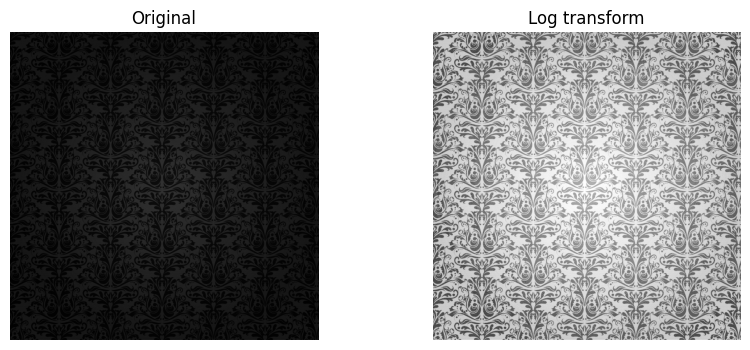

In [4]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(log_img, cmap="gray", vmin=0, vmax=255)
plt.title("Log transform")
plt.axis("off")

plt.show()


## 5) ดูกราฟการแปลงค่า Pixel

กราฟนี้ช่วยให้เห็นว่า input ที่มีค่าน้อยถูกยกขึ้นเร็ว ส่วน input ที่มีค่ามากเริ่มเพิ่มช้าลง


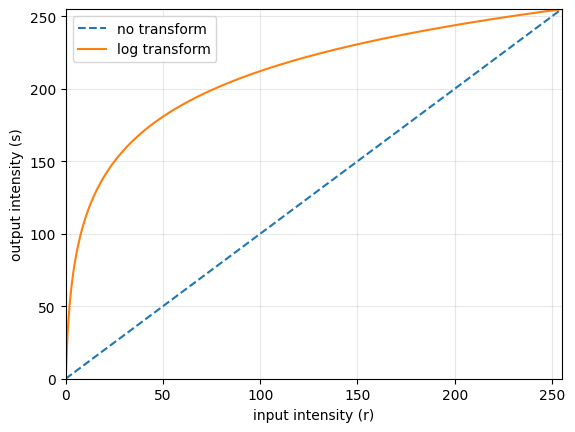

In [5]:
r = np.arange(256, dtype=np.float32)
s = 255.0 * np.log1p(r) / np.log1p(255.0)

plt.plot(r, r, "--", label="no transform")
plt.plot(r, s, label="log transform")
plt.xlabel("input intensity (r)")
plt.ylabel("output intensity (s)")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 6) เปรียบเทียบ Histogram ก่อนและหลัง

Histogram แสดงการกระจายของค่าความเข้มในภาพ หลังแปลงด้วย log ค่าในบริเวณมืดจะถูกกระจายไปยังช่วงที่สว่างขึ้น


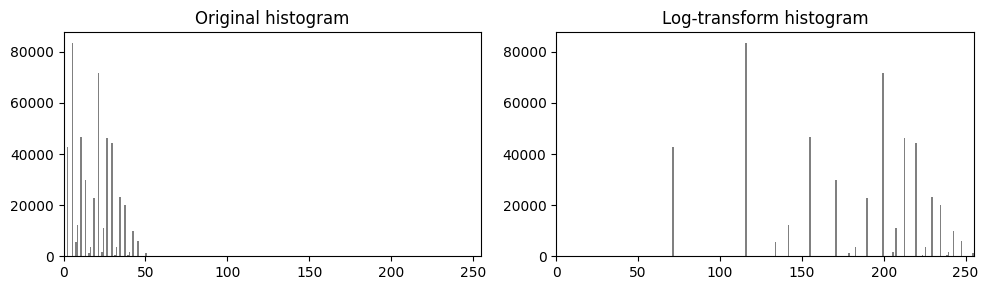

In [6]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Original histogram")
plt.xlim(0, 255)

plt.subplot(1, 2, 2)
plt.hist(log_img.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Log-transform histogram")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()


## 7) วิธีเสริม: Lookup Table (LUT)

สำหรับภาพ 8-bit ค่า pixel มีได้เพียง 256 ค่า คือ 0 ถึง 255 เราจึงคำนวณผลลัพธ์ของแต่ละค่าไว้ล่วงหน้าในตาราง แล้วใช้ `cv2.LUT()` map ทั้งภาพได้รวดเร็ว

แนวคิดนี้ให้ผลเหมือนสูตรเดิม แต่เหมาะเมื่อต้องประมวลผลหลายภาพหรือภาพขนาดใหญ่


Direct method equals LUT: True


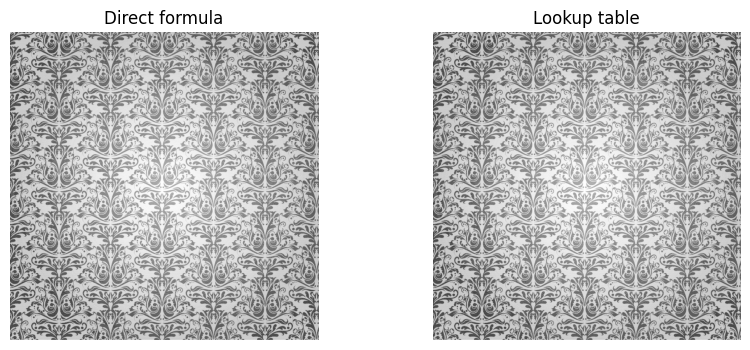

In [7]:
lookup = c * np.log1p(np.arange(256, dtype=np.float32))
lookup = np.clip(lookup, 0, 255).astype(np.uint8)

log_img_lut = cv2.LUT(img, lookup)

print("Direct method equals LUT:", np.array_equal(log_img, log_img_lut))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(log_img, cmap="gray", vmin=0, vmax=255)
plt.title("Direct formula")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(log_img_lut, cmap="gray", vmin=0, vmax=255)
plt.title("Lookup table")
plt.axis("off")

plt.show()


## สรุป

Log transformation เหมาะกับภาพที่รายละเอียดสำคัญอยู่ในบริเวณมืด เพราะช่วยขยายค่าความเข้มต่ำและบีบค่าความเข้มสูง สูตรนี้ใช้งานง่าย แต่ควรระวังว่าหากภาพสว่างอยู่แล้ว ผลลัพธ์อาจดูซีดหรือสว่างเกินไป

**คำถามสำหรับผู้เรียน**

1. ถ้าเปลี่ยนภาพเป็น `./images/dark.png` ผลลัพธ์ต่างจากภาพนี้อย่างไร
2. ถ้าใช้ $c = 255 / \log(1 + 255)$ แทนการใช้ค่าสูงสุดของภาพ ผลลัพธ์ต่างกันหรือไม่
3. Log transform เหมาะกับภาพที่มีปัญหาแบบใด และไม่เหมาะกับภาพแบบใด
